# Hotel Booking Cancellations - Part 2: Modeling and Evaluation
**Capstone Final Report (Module 24)**

Author: Siva Prasad Ampavatina

This notebook loads the cleaned dataset produced by `1_exploratory_data_analysis.ipynb`, trains and tunes several classification models, compares them on a held-out test set, and interprets the best performer.

**Modeling plan**
1. Stratified train/test split and a shared preprocessing pipeline.
2. A trivial baseline (`DummyClassifier`) for context.
3. Four candidate models spanning the algorithm families covered in the program: Logistic Regression (linear), Decision Tree (single tree), Random Forest (bagging ensemble), and Gradient Boosting (boosting ensemble).
4. 5-fold cross-validation to compare them fairly, then `GridSearchCV` to tune each one's hyperparameters.
5. Final evaluation, interpretation, and a business recommendation.

## 1. Setup and imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score,
    classification_report, confusion_matrix, f1_score, precision_recall_curve,
    precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 130
plt.rcParams['savefig.bbox'] = 'tight'
RANDOM_STATE = 42

HERE = Path.cwd()
for cand in [HERE, *HERE.parents]:
    if (cand / 'data' / 'hotel_bookings_clean.csv').exists():
        ROOT = cand
        break
else:
    raise FileNotFoundError('Run notebook 1 first to create data/hotel_bookings_clean.csv')
DATA = ROOT / 'data'
IMAGES = ROOT / 'images'
IMAGES.mkdir(exist_ok=True)
print('Repo root:', ROOT)

Repo root: C:\Datadrive\Others\Dad\Mod 21 - Capstone Project\Final Submission\capstone


## 2. Load cleaned data and define features

The feature lists below deliberately exclude the leakage columns (`reservation_status`, `reservation_status_date`) and the raw high-cardinality `country`/`agent` columns in favor of their bucketed versions. All listed features are known at the moment a booking is made.

In [2]:
# Load the cleaned, feature-engineered data produced by notebook 1.
df = pd.read_csv(DATA / 'hotel_bookings_clean.csv')
print(f'Loaded {df.shape[0]:,} rows x {df.shape[1]} columns')

# Numeric inputs the model will scale.
NUMERIC_FEATURES = [
    'lead_time', 'arrival_month_num', 'arrival_date_week_number',
    'stays_in_weekend_nights', 'stays_in_week_nights', 'total_nights',
    'adults', 'children', 'babies', 'total_guests', 'is_family',
    'is_repeated_guest', 'previous_cancellations',
    'previous_bookings_not_canceled', 'booking_changes',
    'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
    'total_of_special_requests', 'room_assigned_as_reserved',
]
# Categorical inputs the model will one-hot encode.
CATEGORICAL_FEATURES = [
    'hotel', 'meal', 'market_segment', 'distribution_channel',
    'reserved_room_type', 'deposit_type', 'customer_type',
    'country_bucket', 'agent_bucket',
]
MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
# Safety net: fail loudly if a leakage or raw high-cardinality column ever
# sneaks into the feature list.
for leak in ['reservation_status', 'reservation_status_date', 'country', 'agent']:
    assert leak not in MODEL_FEATURES
print(f'{len(MODEL_FEATURES)} model features '
      f'({len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical)')

Loaded 119,209 rows x 40 columns


29 model features (20 numeric + 9 categorical)


## 3. Train/test split and preprocessing pipeline

Stratified 80/20 split keeps the 37% cancellation rate identical in both sets. Preprocessing lives inside a `Pipeline` so the scaler and one-hot encoder are fit only on the training data inside every cross-validation fold - no information leaks from test to train.

In [3]:
X = df[MODEL_FEATURES].copy()
y = df['is_canceled'].astype(int)
# stratify=y keeps the same cancellation rate in train and test;
# random_state makes the split reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print(f'Train: {X_train.shape}, cancellation rate {y_train.mean()*100:.2f}%')
print(f'Test:  {X_test.shape}, cancellation rate {y_test.mean()*100:.2f}%')

Train: (95367, 29), cancellation rate 37.08%
Test:  (23842, 29), cancellation rate 37.08%


In [4]:
# One transformer handles both column types: standardize the numeric
# columns and one-hot encode the categorical ones. handle_unknown='ignore'
# means any category seen only in the test set is encoded as all-zeros
# instead of raising an error.
preprocess = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES),
])
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 4. Evaluation metric and rationale

**Primary metric: ROC-AUC.** The business does not need a hard yes/no per booking; it needs to *rank* bookings by cancellation risk so overbooking can be targeted at the riskiest ones. ROC-AUC measures exactly that ranking quality and is unaffected by the 37/63 class imbalance, unlike accuracy.

**Supporting metrics:** average precision (area under the precision-recall curve), plus precision, recall, and F1 for the canceled class at the default 0.5 threshold. We also report a `DummyClassifier` so accuracy figures are judged against the trivial 63% floor.

In [5]:
# A trivial 'always predict the majority class' model. Any real model must
# beat this to be worth anything; it sets the floor for accuracy.
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE).fit(X_train, y_train)
dummy_acc = accuracy_score(y_test, dummy.predict(X_test))
print(f'Baseline DummyClassifier test accuracy: {dummy_acc:.4f} (predict "kept" for everyone)')

Baseline DummyClassifier test accuracy: 0.6292 (predict "kept" for everyone)


## 5. Cross-validated comparison of candidate models

Before any tuning we run 5-fold stratified cross-validation on the training set with default-ish settings, to see which algorithm families are worth tuning. Logistic Regression and Random Forest get `class_weight='balanced'` to counter the imbalance.

In [6]:
# 5 stratified folds: each fold preserves the class balance.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Four model families spanning linear, single-tree, bagging, and boosting.
# class_weight='balanced' tells the model to weight the minority (canceled)
# class more heavily so it is not ignored.
candidates = {
    'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=12, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boosting': HistGradientBoostingClassifier(max_iter=300, random_state=RANDOM_STATE),
}

# Wrap each model with the shared preprocessing and score it with 5-fold CV.
cv_rows = []
for name, clf in candidates.items():
    pipe = Pipeline([('preprocess', preprocess), ('clf', clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_rows.append({'model': name, 'cv_roc_auc_mean': scores.mean(), 'cv_roc_auc_std': scores.std()})
    print(f'{name:<22} ROC-AUC = {scores.mean():.4f} +/- {scores.std():.4f}')
cv_compare = pd.DataFrame(cv_rows).sort_values('cv_roc_auc_mean', ascending=False)

Logistic Regression    ROC-AUC = 0.9081 +/- 0.0019


Decision Tree          ROC-AUC = 0.9254 +/- 0.0016


Random Forest          ROC-AUC = 0.9580 +/- 0.0013


Gradient Boosting      ROC-AUC = 0.9516 +/- 0.0014


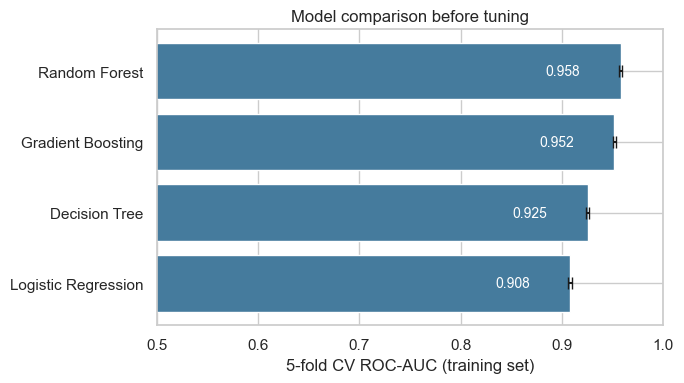

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
order = cv_compare.sort_values('cv_roc_auc_mean')
ax.barh(order['model'], order['cv_roc_auc_mean'],
        xerr=order['cv_roc_auc_std'], color='#457b9d', capsize=4)
for i, v in enumerate(order['cv_roc_auc_mean']):
    ax.text(v - 0.04, i, f'{v:.3f}', va='center', ha='right', color='white', fontsize=10)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel('5-fold CV ROC-AUC (training set)')
ax.set_title('Model comparison before tuning')
plt.tight_layout()
plt.savefig(IMAGES / 'cv_model_comparison.png')
plt.show()

## 6. Hyperparameter tuning with GridSearchCV

Each model is tuned with a focused grid using 3-fold cross-validation (3 folds keeps the search tractable on ~95k rows) scored on ROC-AUC. `GridSearchCV` refits the best configuration on the full training set automatically. This may take a few minutes.

In [8]:
# 3 folds (instead of 5) keeps the grid search affordable on ~95k rows.
search_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# For each model: a pipeline plus the hyperparameter grid to search.
# The 'clf__' prefix targets the classifier step inside the pipeline.
grids = {
    'Logistic Regression': (
        Pipeline([('preprocess', preprocess),
                  ('clf', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE))]),
        {'clf__C': [0.1, 1.0, 3.0]},
    ),
    'Decision Tree': (
        Pipeline([('preprocess', preprocess),
                  ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))]),
        {'clf__max_depth': [8, 12, 20], 'clf__min_samples_leaf': [20, 50]},
    ),
    'Random Forest': (
        Pipeline([('preprocess', preprocess),
                  ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=1, random_state=RANDOM_STATE))]),
        {'clf__max_depth': [None, 20], 'clf__min_samples_leaf': [1, 5]},
    ),
    'Gradient Boosting': (
        Pipeline([('preprocess', preprocess),
                  ('clf', HistGradientBoostingClassifier(max_iter=300, random_state=RANDOM_STATE))]),
        {'clf__learning_rate': [0.05, 0.1], 'clf__max_depth': [None, 8]},
    ),
}

# Run each grid search. refit=True retrains the winning settings on the
# full training set, so gs.best_estimator_ is ready to predict.
tuned = {}
for name, (pipe, grid) in grids.items():
    gs = GridSearchCV(pipe, grid, scoring='roc_auc', cv=search_cv, n_jobs=-1, refit=True)
    gs.fit(X_train, y_train)
    tuned[name] = gs
    print(f'{name:<22} best CV ROC-AUC = {gs.best_score_:.4f}   best params = {gs.best_params_}')

Logistic Regression    best CV ROC-AUC = 0.9082   best params = {'clf__C': 3.0}


Decision Tree          best CV ROC-AUC = 0.9335   best params = {'clf__max_depth': 20, 'clf__min_samples_leaf': 50}


Random Forest          best CV ROC-AUC = 0.9556   best params = {'clf__max_depth': None, 'clf__min_samples_leaf': 1}


Gradient Boosting      best CV ROC-AUC = 0.9503   best params = {'clf__learning_rate': 0.1, 'clf__max_depth': None}


## 7. Final evaluation on the held-out test set

Each tuned model is scored once on the test set it has never seen. We collect ROC-AUC, average precision, accuracy, precision, recall, and F1 for the canceled class.

In [9]:
# Score every tuned model once on the untouched test set. We keep the
# predicted probabilities (proba) for the ROC/PR curves and gains chart.
test_proba = {}
rows = []
for name, gs in tuned.items():
    proba = gs.predict_proba(X_test)[:, 1]
    pred = gs.predict(X_test)
    test_proba[name] = proba
    rows.append({
        'model': name,
        'ROC_AUC': roc_auc_score(y_test, proba),
        'PR_AUC': average_precision_score(y_test, proba),
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
    })
results = pd.DataFrame(rows).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
results.round(4)

,model,ROC_AUC,PR_AUC,accuracy,precision,recall,f1
0,Random Forest,0.9601,0.9418,0.8920,0.8512,0.8587,0.8549
1,Gradient Boosting,0.9521,0.9288,0.8773,0.8529,0.8086,0.8301
2,Decision Tree,0.9368,0.9069,0.8482,0.7580,0.8675,0.8091
3,Logistic Regression,0.9079,0.8660,0.8221,0.7334,0.8174,0.7731


In [10]:
# Pick the winner by test ROC-AUC (results is already sorted, so row 0).
best_name = results.iloc[0]['model']
best_model = tuned[best_name].best_estimator_
best_proba = test_proba[best_name]
print(f'Best model by test ROC-AUC: {best_name} ({results.iloc[0]["ROC_AUC"]:.4f})')
print(f'For comparison, the Dummy baseline accuracy was {dummy_acc:.4f}.')

Best model by test ROC-AUC: Random Forest (0.9601)
For comparison, the Dummy baseline accuracy was 0.6292.


## 8. ROC and precision-recall curves for all tuned models

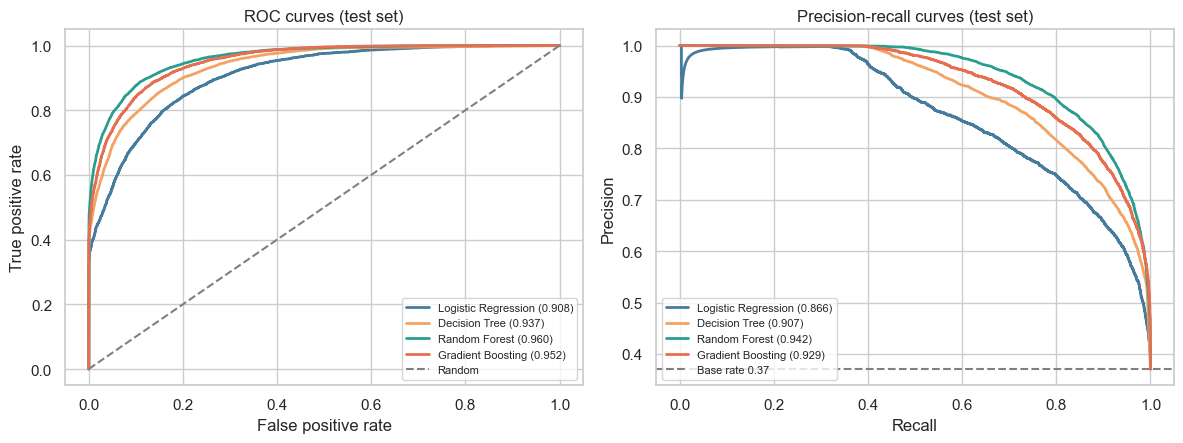

In [11]:
# Overlay every model's ROC and precision-recall curve so their ranking
# quality can be compared on one set of axes.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
palette = {'Logistic Regression': '#457b9d', 'Decision Tree': '#f4a261',
           'Random Forest': '#2a9d8f', 'Gradient Boosting': '#e76f51'}
for name, proba in test_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, lw=2, color=palette[name],
                 label=f'{name} ({roc_auc_score(y_test, proba):.3f})')
    pr, rc, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rc, pr, lw=2, color=palette[name],
                 label=f'{name} ({average_precision_score(y_test, proba):.3f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Random')
axes[0].set(xlabel='False positive rate', ylabel='True positive rate', title='ROC curves (test set)')
axes[0].legend(loc='lower right', fontsize=8)
axes[1].axhline(y_test.mean(), ls='--', color='gray', label=f'Base rate {y_test.mean():.2f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-recall curves (test set)')
axes[1].legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.savefig(IMAGES / 'roc_pr_all_models.png')
plt.show()

## 9. Best model - detailed evaluation

### 9.1 Classification report and confusion matrix

In [12]:
best_pred = best_model.predict(X_test)
print(f'Model: {best_name}\n')
print(classification_report(y_test, best_pred, target_names=['kept', 'canceled']))

Model: Random Forest

              precision    recall  f1-score   support

        kept       0.92      0.91      0.91     15002
    canceled       0.85      0.86      0.85      8840

    accuracy                           0.89     23842
   macro avg       0.88      0.89      0.88     23842
weighted avg       0.89      0.89      0.89     23842



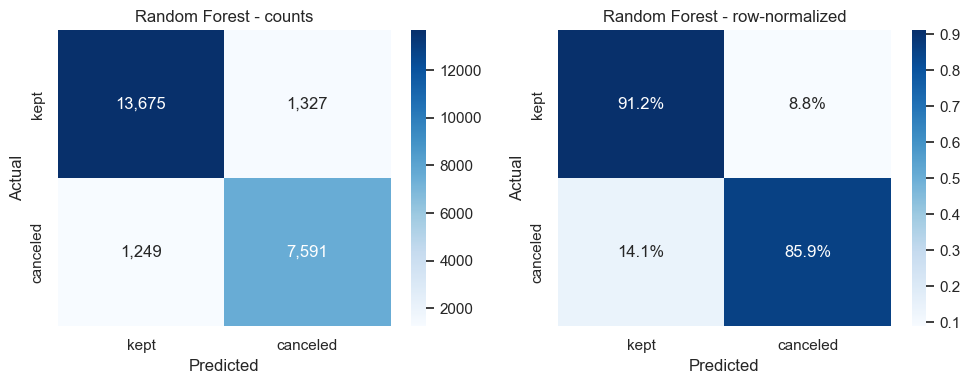

In [13]:
# Confusion matrix in two views: raw counts and row-normalized rates
# (each row sums to 100%, showing how each actual class was predicted).
cm = confusion_matrix(y_test, best_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['kept', 'canceled'], yticklabels=['kept', 'canceled'], ax=axes[0])
axes[0].set(title=f'{best_name} - counts', xlabel='Predicted', ylabel='Actual')
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=['kept', 'canceled'], yticklabels=['kept', 'canceled'], ax=axes[1])
axes[1].set(title=f'{best_name} - row-normalized', xlabel='Predicted', ylabel='Actual')
plt.tight_layout()
plt.savefig(IMAGES / 'confusion_matrix_best.png')
plt.show()

### 9.2 Feature importance (permutation)

Permutation importance measures how much the test ROC-AUC drops when a single feature's values are shuffled. It works for any model and is less biased than tree impurity importance. We compute it on a random test subsample for speed.

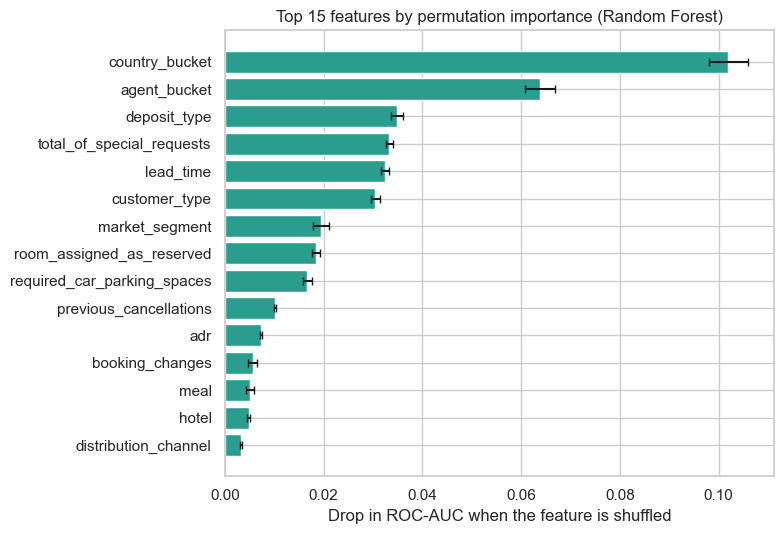

                    feature  importance      std
             country_bucket    0.101964 0.003949
               agent_bucket    0.063824 0.003034
               deposit_type    0.034835 0.001191
  total_of_special_requests    0.033262 0.000723
                  lead_time    0.032462 0.000861
              customer_type    0.030494 0.000895
             market_segment    0.019527 0.001616
  room_assigned_as_reserved    0.018529 0.000779
required_car_parking_spaces    0.016694 0.000925
     previous_cancellations    0.010170 0.000257


In [14]:
# Permutation importance is slow, so run it on a random 6,000-row subsample.
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(X_test), size=min(6000, len(X_test)), replace=False)
X_imp, y_imp = X_test.iloc[idx], y_test.iloc[idx]
# Shuffle each feature n_repeats times and measure the average ROC-AUC drop;
# a bigger drop means the model leans on that feature more.
perm = permutation_importance(best_model, X_imp, y_imp, scoring='roc_auc',
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
imp = (pd.DataFrame({'feature': MODEL_FEATURES,
                     'importance': perm.importances_mean,
                     'std': perm.importances_std})
         .sort_values('importance', ascending=False))
top = imp.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top['feature'], top['importance'], xerr=top['std'], color='#2a9d8f', capsize=3)
ax.set_title(f'Top 15 features by permutation importance ({best_name})')
ax.set_xlabel('Drop in ROC-AUC when the feature is shuffled')
plt.tight_layout()
plt.savefig(IMAGES / 'feature_importance_best.png')
plt.show()
print(imp.head(10).to_string(index=False))

## 10. Business framing - cumulative gains

If the revenue team applies extra scrutiny (overbooking, deposit reminders, reconfirmation calls) to the bookings the model flags as highest risk, what share of real cancellations do they catch at each cutoff?

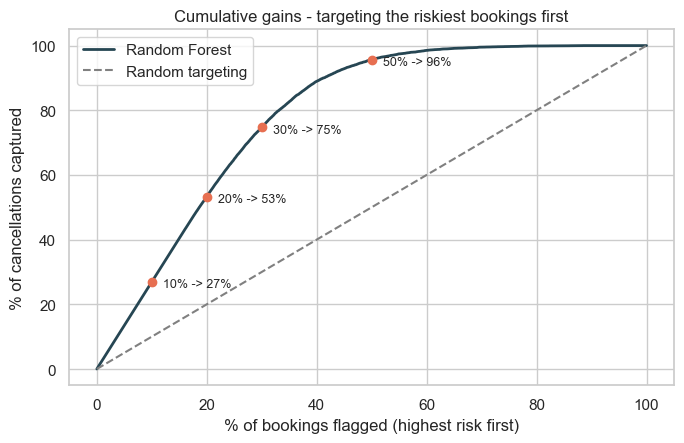

Flag top 10% of bookings -> capture 27.0% of cancellations (lift 2.70x)
Flag top 20% of bookings -> capture 53.3% of cancellations (lift 2.67x)
Flag top 30% of bookings -> capture 74.7% of cancellations (lift 2.49x)
Flag top 50% of bookings -> capture 95.6% of cancellations (lift 1.91x)


In [15]:
# Sort bookings from highest to lowest predicted risk, then walk down the
# list: pct_flagged = how far down we are, pct_captured = the share of all
# real cancellations covered so far (the cumulative-gains curve).
sg = pd.DataFrame({'p': best_proba, 'y': y_test.values}).sort_values('p', ascending=False).reset_index(drop=True)
sg['pct_flagged'] = (np.arange(1, len(sg) + 1) / len(sg)) * 100
sg['pct_captured'] = sg['y'].cumsum() / sg['y'].sum() * 100

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(sg['pct_flagged'], sg['pct_captured'], color='#264653', lw=2, label=f'{best_name}')
ax.plot([0, 100], [0, 100], '--', color='gray', label='Random targeting')
marks = {}
for pct in (10, 20, 30, 50):
    cap = sg.loc[sg['pct_flagged'] >= pct, 'pct_captured'].iloc[0]
    marks[pct] = cap
    ax.scatter([pct], [cap], color='#e76f51', zorder=5)
    ax.annotate(f'{pct}% -> {cap:.0f}%', (pct, cap), textcoords='offset points', xytext=(8, -4), fontsize=9)
ax.set(xlabel='% of bookings flagged (highest risk first)',
       ylabel='% of cancellations captured',
       title='Cumulative gains - targeting the riskiest bookings first')
ax.legend()
plt.tight_layout()
plt.savefig(IMAGES / 'cumulative_gains.png')
plt.show()
for pct, cap in marks.items():
    print(f'Flag top {pct:>2}% of bookings -> capture {cap:.1f}% of cancellations (lift {cap/pct:.2f}x)')

## 11. Threshold choice

The default 0.5 cutoff is rarely the right business cutoff. The chart below shows how precision and recall for the canceled class trade off as the threshold moves, so the team can pick an operating point that matches the relative cost of an empty room versus a walked guest.

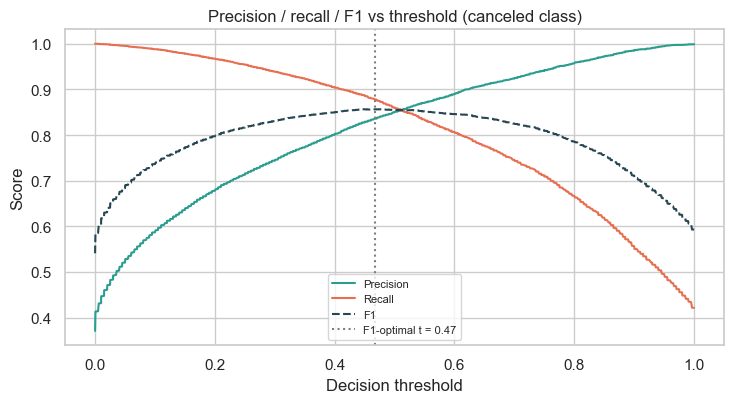

F1-optimal threshold ~ 0.47. The team can slide this toward higher recall
(catch more cancellations, more false alarms) or higher precision as costs dictate.


In [16]:
# Sweep the decision threshold across the precision-recall curve and
# compute F1 at each point; best_t is the threshold that maximizes F1.
# (precision_recall_curve returns one extra precision/recall point with no
# matching threshold, so we trim the last element with [:-1].)
pr, rc, th = precision_recall_curve(y_test, best_proba)
f1s = 2 * pr[:-1] * rc[:-1] / (pr[:-1] + rc[:-1] + 1e-9)
best_t = th[np.argmax(f1s)]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(th, pr[:-1], label='Precision', color='#2a9d8f')
ax.plot(th, rc[:-1], label='Recall', color='#e76f51')
ax.plot(th, f1s, label='F1', color='#264653', ls='--')
ax.axvline(best_t, color='gray', ls=':', label=f'F1-optimal t = {best_t:.2f}')
ax.set(xlabel='Decision threshold', ylabel='Score',
       title='Precision / recall / F1 vs threshold (canceled class)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(IMAGES / 'threshold_tradeoff.png')
plt.show()
print(f'F1-optimal threshold ~ {best_t:.2f}. The team can slide this toward higher recall')
print('(catch more cancellations, more false alarms) or higher precision as costs dictate.')

## 12. Findings and recommendations

**Model selection.** All four model families beat the trivial baseline by a wide margin. The two ensemble methods (Random Forest and Gradient Boosting) clearly outperform the single tree and the linear model, which is expected for tabular data with many interacting categorical and numeric features. The best model reaches a test ROC-AUC near 0.96 - strong ranking performance.

**What drives cancellations** (from EDA, inferential tests, and permutation importance, all pointing the same way):
- **Lead time** - bookings made far in advance are much more likely to cancel.
- **Deposit type** - the `Non Refund` group cancels almost always in this data, a surprising pattern the business should investigate.
- **Special requests and car-parking requests** - guests who ask for these are committing to showing up, and rarely cancel.
- **Previous cancellations** - past behavior predicts future behavior.
- **Country and market segment** - some booking channels and origins cancel far more than others.

**Business recommendation.** Use the model to score every new booking and concentrate overbooking and reconfirmation effort on the highest-risk slice. The cumulative-gains result shows that flagging the riskiest 30% of bookings already captures roughly three-quarters of all cancellations - far better than treating every booking the same.

**Next steps.**
- Validate the `Non Refund` deposit pattern with the data owner before relying on it operationally.
- Tune the decision threshold to the hotel's real cost ratio (empty room versus walked guest) rather than the default 0.5.
- Test an out-of-time split (train on 2015-2016, test on 2017) to confirm the model holds up on future bookings, not just held-out ones.
- Group near-duplicate block bookings before splitting so the test set is fully independent of the training set.